# Phân Tích Các Yếu Tố Ảnh Hưởng Đến Xác Suất Phát Sinh Liên Hệ Trên Chợ Tốt BĐS

**Datathon 2026 — Chợ Tốt Bất Động Sản**

---

## Executive Summary

Chợ Tốt BĐS ghi nhận hàng trăm triệu lượt xem tin đăng (pageview), nhưng chỉ một phần rất nhỏ chuyển hóa thành hành động liên hệ thật sự — **view_phone**, **contact_chat**, **contact_zalo**, **contact_sms** — (gọi chung là **hard contact / lead**).

> **Vấn đề cốt lõi**: Hơn 90% traffic bị thất thoát ở bước chuyển từ pageview sang hard contact. Notebook này phân tích **các yếu tố ảnh hưởng đến xác suất một tin đăng phát sinh liên hệ**, từ đó đề xuất giải pháp cụ thể.

### Phương pháp phân tích

| Bước | Nội dung |
|------|----------|
| **1. Funnel Overview** | Xác định điểm rơi chính của phễu chuyển đổi |
| **2. Phân tích theo từng yếu tố** | Category, giá, seller type, chất lượng tin đăng, thời gian, thiết bị, hành vi người dùng |
| **3. Tổng hợp Root Cause** | Bảng tổng hợp các yếu tố ảnh hưởng và mức độ tác động |
| **4. Đề xuất giải pháp** | Giải pháp thực tiễn cho từng nguyên nhân |

### Định nghĩa sự kiện

| Nhóm | Event types | Ý nghĩa |
|------|-------------|---------|
| **Hard contact** | `view_phone`, `contact_chat`, `contact_zalo`, `contact_sms` | Liên hệ trực tiếp — **lead thật** |
| **Soft positive** | `other_interaction` | Tương tác tích cực nhưng chưa rõ ý định |
| **Pageview** | `pageview` | Xem chi tiết tin đăng |

> **Lưu ý**: Trường `purchased` trong dữ liệu là **purchase proxy** (nhãn dự đoán), không phải giao dịch thật.

---
# 1. Setup & Configuration

In [32]:
import os, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq

warnings.filterwarnings('ignore')
plt.style.use('default')

# ── Storytelling with Data (SWD) Aesthetics ──
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.figsize': (12, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.edgecolor': '#B0BEC5',
    'axes.labelcolor': '#546E7A',
    'text.color': '#37474F',
    'xtick.color': '#78909C',
    'ytick.color': '#78909C',
    'axes.grid': False,
    'grid.color': '#ECEFF1',
    'grid.alpha': 0.8,
    'grid.linestyle': '-',
    'axes.titlepad': 15,
})

# Thống nhất màu sắc (Storytelling with Data)
C_ACCENT  = '#E67E22' # Cam rực rỡ (Điểm nhấn chính)
C_PRIMARY = '#2980B9' # Xanh dương (Tương phản/Mảng khác)
C_MUTED   = '#E0E0E0' # Xám nhạt (Bối cảnh/Context)
C_DARK    = '#34495E' # Xám đen (Nhấn chữ)
C_SUCCESS = C_ACCENT  # Giữ lại biến cũ để không lỗi code
C_WARNING = C_ACCENT  # Giữ lại biến cũ để không lỗi code

def save_fig(name, fig):
    out_dir = Path('reports/figures')
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f'{name}.png', dpi=300, bbox_inches='tight', facecolor='white')

# ── Định nghĩa các hằng số đường dẫn (Paths) ──
base_dir = Path.cwd()
DATA_DIR = base_dir / 'data'
DIM_PATH = DATA_DIR / 'processed' / 'dim_listing_cleaned' / 'dim_listing_cleaned.parquet'
INTER_DIR = DATA_DIR / 'processed' / 'fact_user_ad_interactions'
SNAP_PATH = DATA_DIR / 'raw' / 'fact_listing_snapshot'
AGG_DIR = DATA_DIR / 'aggregated'

# ── Hằng số & Hàm tiện ích ──
HARD_CONTACT = ["view_phone","contact_chat","contact_zalo","contact_sms"]
SOFT_POSITIVE = ["other_interaction"]
CAT_MAP = {1010:"Phòng trọ/Studio",1020:"Căn hộ/Chung cư",1030:"Nhà ở",1040:"Đất",1050:"Dự án mở bán"}

def cr(c, v): 
    return np.where(v>0, c/v, 0.0) if hasattr(c,'__len__') else (c/v if v else 0)

def map_cat(df, col='category'):
    df = df.copy(); df[col] = df[col].map(CAT_MAP).fillna(df[col])
    return df

def fmt_n(n):
    return f"{n:,.0f}".replace(',','.')

PAL5 = ["#2563EB","#EF4444","#10B981","#F59E0B","#8B5CF6"]

C_TEXT = "#37474F"


---
# 2. Data Loading

> **Chiến lược bộ nhớ**: `clean_fact_user_events` (~25GB) đã được pre-aggregate bằng DuckDB thành các file nhỏ trong `data/aggregated/`. Notebook chỉ load các file nhỏ này — **không bao giờ load raw events vào RAM**.

In [33]:
# ── 2.1 dim_listing ──
dim_cols = ['item_id','seller_id','category','seller_type','ad_type','ad_status',
            'area_sqm','bedrooms','bathrooms','floors','width_m','legal_status',
            'house_type','furnishing','city_name','district_name','ward_name',
            'price_bucket','images_count','posted_date','expected_expired_date','is_project']
dim = pq.read_table(str(DIM_PATH), columns=dim_cols).to_pandas()
print(f"dim_listing: {dim.shape}")

# ── 2.2 fact_user_ad_interactions ──
inter_files = sorted(INTER_DIR.glob("*.parquet"))
inter = pd.concat([pq.read_table(str(f)).to_pandas() for f in inter_files], ignore_index=True)
print(f"fact_interactions: {inter.shape}")

# ── 2.3 fact_listing_snapshot ──
snap_cols = ['item_id','date','views_24h','contacts_24h','listing_age_days']
snap = pq.read_table(str(SNAP_PATH), columns=snap_cols).to_pandas()
print(f"fact_snapshot: {snap.shape}")

# ── 2.4 Pre-aggregated event tables ──
evt_type     = pd.read_parquet(AGG_DIR / 'events_by_type.parquet')
evt_cat_type = pd.read_parquet(AGG_DIR / 'events_by_category_type.parquet')
evt_login    = pd.read_parquet(AGG_DIR / 'events_by_login_type.parquet')
evt_hour     = pd.read_parquet(AGG_DIR / 'events_by_hour_type.parquet')
evt_dow      = pd.read_parquet(AGG_DIR / 'events_by_dow_type.parquet')
evt_date     = pd.read_parquet(AGG_DIR / 'events_by_date_type.parquet')
evt_city     = pd.read_parquet(AGG_DIR / 'events_by_city_type.parquet')
evt_device   = pd.read_parquet(AGG_DIR / 'events_by_device_type.parquet')
sess_dist    = pd.read_parquet(AGG_DIR / 'session_depth_dist.parquet')
dwell_sample = pd.read_parquet(AGG_DIR / 'dwell_time_sample.parquet')
surf_pos     = pd.read_parquet(AGG_DIR / 'surface_position_device.parquet')
item_evt_agg = pd.read_parquet(AGG_DIR / 'item_event_agg.parquet')

evt_hour['hour'] = evt_hour['hour'].astype(int)
evt_dow['day_of_week'] = evt_dow['day_of_week'].astype(int)

print(f"\nPre-aggregated tables loaded:")
print(f"  item_evt_agg: {len(item_evt_agg):,} items")
print(f"  dwell_sample: {len(dwell_sample):,} rows")
print(f"  session_depth_dist: {len(sess_dist)} buckets")
print("\nALL DATA LOADED")

dim_listing: (3107114, 22)
fact_interactions: (25486445, 10)
fact_snapshot: (19762167, 5)

Pre-aggregated tables loaded:
  item_evt_agg: 758,546 items
  dwell_sample: 168,740 rows
  session_depth_dist: 6 buckets

ALL DATA LOADED


---
# 3. Funnel Overview — Xác Định Điểm Rơi Chính

> Trước khi phân tích các yếu tố chi tiết, ta cần xác định **ở đâu trong phễu chuyển đổi mà traffic bị mất nhiều nhất**.

## 3.1 Biểu đồ 1: Phễu chuyển đổi (Funnel) Tổng Quan

In [34]:
# ── Build funnel ──
pv = evt_type[evt_type['event_type']=='pageview']['n_events'].sum()
hc = evt_type[evt_type['event_type'].isin(HARD_CONTACT)]['n_events'].sum()
soft = evt_type[evt_type['event_type'].isin(SOFT_POSITIVE)]['n_events'].sum()
chats = inter[inter['chat_message_count']>0].shape[0]
purchased = inter['purchased'].sum()

funnel = pd.DataFrame({
    'stage':['Pageview','Hard Contact','Chat','Purchase Proxy'],
    'count':[pv, hc, chats, purchased]
})
funnel['pct_of_pv'] = (funnel['count']/pv*100).round(2)
funnel['drop_pct'] = [0]+[(1-funnel['count'].iloc[i]/funnel['count'].iloc[i-1])*100 for i in range(1,len(funnel))]

print("="*60)
print("FUNNEL CHUYỂN ĐỔI CHỢ TỐT BĐS")
print("="*60)
for _,r in funnel.iterrows():
    print(f"  {r['stage']:20s}  {fmt_n(r['count']):>10s}  ({r['pct_of_pv']:.2f}% of PV)")
print(f"\n  >>> Thất thoát lớn nhất: Pageview -> Hard Contact ({funnel.iloc[1]['drop_pct']:.1f}% mất)")

FUNNEL CHUYỂN ĐỔI CHỢ TỐT BĐS
  Pageview              65.548.923  (100.00% of PV)
  Hard Contact           5.509.095  (8.40% of PV)
  Chat                   1.786.887  (2.73% of PV)
  Purchase Proxy           586.484  (0.89% of PV)

  >>> Thất thoát lớn nhất: Pageview -> Hard Contact (91.6% mất)


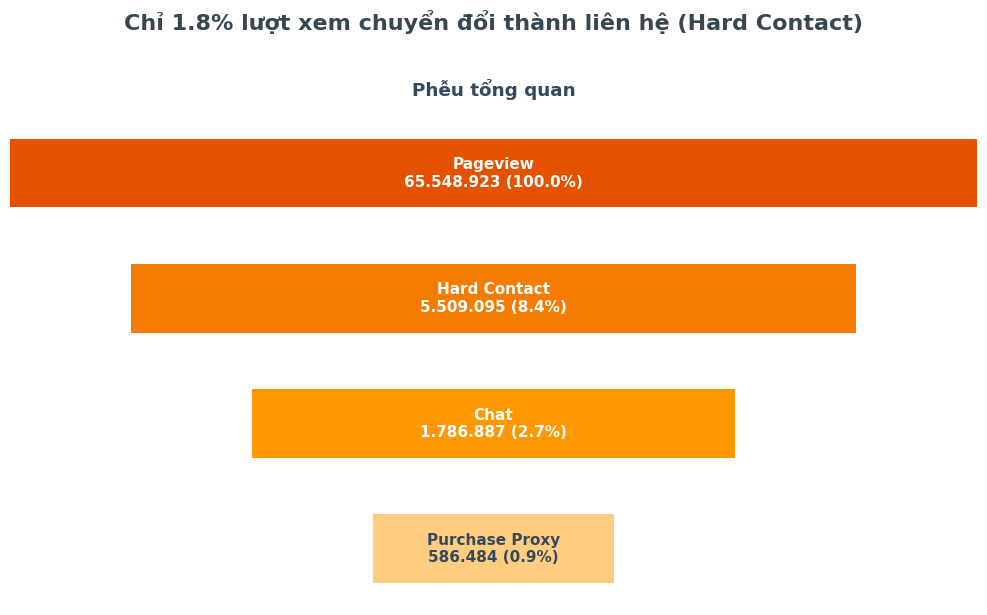

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Chỉ 1.8% lượt xem chuyển đổi thành liên hệ (Hard Contact)', fontweight='bold', fontsize=16, y=1.02)

# Colors: Orange getting lighter towards the bottom
colors_f = ['#E65100', '#F57C00', '#FF9800', '#FFCC80']

# Định nghĩa độ rộng cố định giảm dần cho các thanh phễu để tránh bị quá nhỏ
fixed_widths = [1.0, 0.75, 0.50, 0.25]

for i, r in funnel.iterrows():
    # Sử dụng độ rộng cố định thay vì tính theo tỷ lệ count thực tế
    w = fixed_widths[i]
    
    # Vẽ thanh phễu (Căn giữa bằng cách tính left = (1 - w) / 2)
    ax.barh(len(funnel) - 1 - i, w, height=0.55, left=(1 - w) / 2, color=colors_f[i], edgecolor='none')
    
    # Hiển thị số liệu thực tế ở tâm thanh phễu
    tc = 'white' if i < 3 else C_DARK # Text màu tối cho màu cam nhạt cuối cùng
    ax.text(0.5, len(funnel) - 1 - i, f"{r['stage']}\n{fmt_n(r['count'])} ({r['pct_of_pv']:.1f}%)",
            ha='center', va='center', fontsize=11, fontweight='bold', color=tc)

ax.set_xlim(0, 1)
ax.axis('off')
ax.set_title('Phễu tổng quan', fontweight='bold', loc='center', color=C_DARK)

fig.tight_layout()
save_fig('01_funnel_overview', fig)


### Kết luận Funnel

> **Traffic không thiếu**, vấn đề là **chuyển hóa traffic thành hard lead**. Bước rơi lớn nhất nằm ở **Pageview → Hard Contact** — đây là nơi cần tập trung cải thiện.

**Câu hỏi tiếp theo**: *Yếu tố nào quyết định việc một tin đăng có phát sinh liên hệ hay không?*

---

### Khác biệt cốt lõi: Mua Bán vs Cho Thuê

> So sánh funnel riêng cho **Mua Bán (sell)** và **Cho Thuê (let)** để thấy sự khác biệt về hành vi chuyển đổi.

**Ghi chú**:  Phễu chuyển đổi của **Cho Thuê** và **Mua Bán** có đặc trưng khác nhau rõ rệt:
- **Cho Thuê**: Nhu cầu cấp thiết hơn → Hard Contact Rate thường **cao hơn**.
- **Mua Bán**: Quyết định mua nhà cần nhiều thời gian cân nhắc → Hard Contact Rate **thấp hơn** nhưng mỗi lead có giá trị cao hơn.
- Cần chiến lược conversion **khác nhau** cho từng phân khúc.

> **Mức tác động: ⬆️ Cao**

# 4. Phân Tích Các Yếu Tố Ảnh Hưởng Đến Xác Suất Phát Sinh Liên Hệ

> Mỗi yếu tố dưới đây được phân tích độc lập để đo lường mức ảnh hưởng lên **hard contact rate** (= hard contacts / pageviews).

## 4.1 Biểu đồ 2: Phân tích Contact Rate theo Mức giá

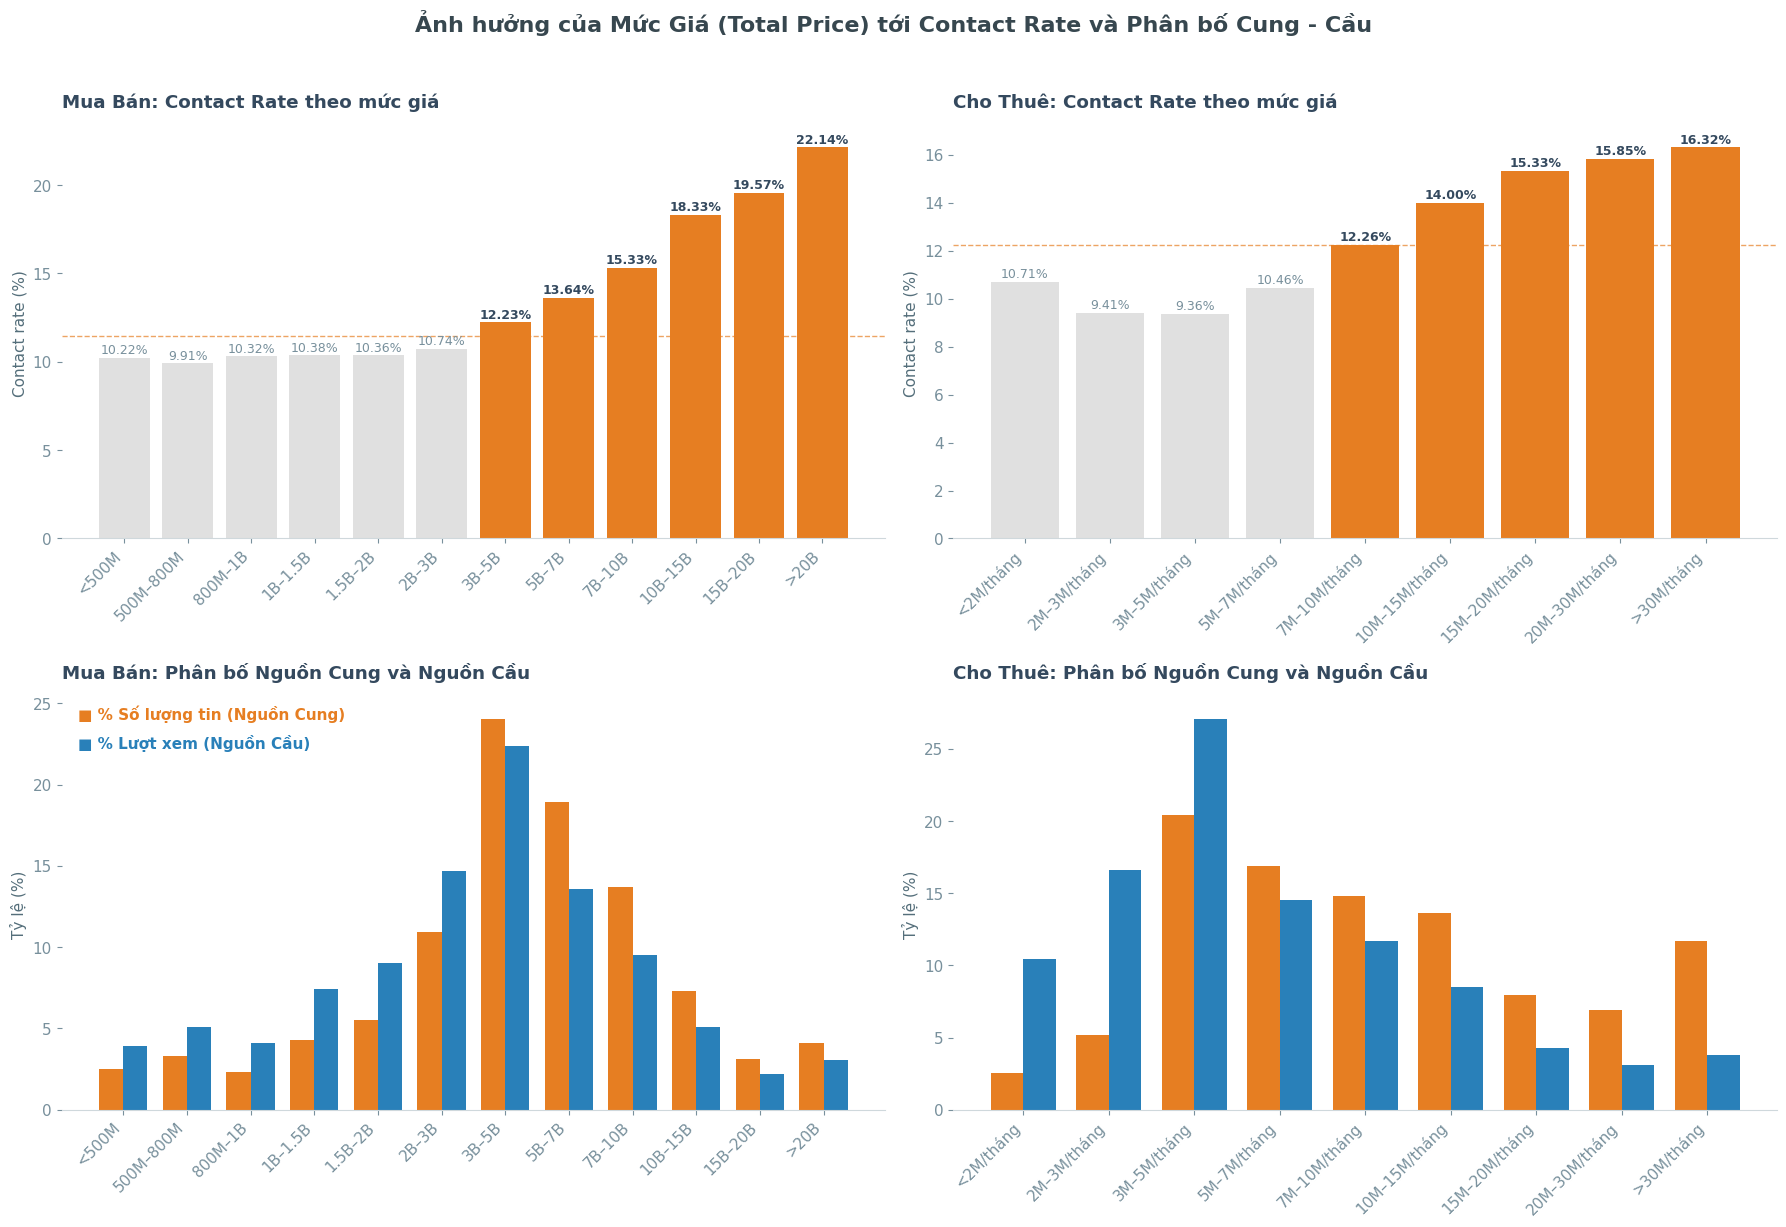

In [36]:
# ── Phân tích Contact Rate và Cung-Cầu theo MỨC GIÁ (Total Price) ──
order_sell = ['<500M', '500M–800M', '800M–1B', '1B–1.5B', '1.5B–2B', '2B–3B', '3B–5B', '5B–7B', '7B–10B', '10B–15B', '15B–20B', '>20B']
order_let = ['<2M/tháng', '2M–3M/tháng', '3M–5M/tháng', '5M–7M/tháng', '7M–10M/tháng', '10M–15M/tháng', '15M–20M/tháng', '20M–30M/tháng', '>30M/tháng']

if 'inter_dim' not in locals():
    inter_dim = inter.merge(dim[['item_id','price_bucket','ad_type']], on='item_id', how='left')

cung_sell = dim[dim['ad_type']=='sell']['price_bucket'].value_counts().reindex(order_sell).fillna(0)
cung_let = dim[dim['ad_type']=='let']['price_bucket'].value_counts().reindex(order_let).fillna(0)

sub_sell = inter_dim[inter_dim['ad_type'] == 'sell']
ps_sell = sub_sell.groupby('price_bucket').agg(views=('adview_count','sum'), leads=('lead_count','sum')).reindex(order_sell).fillna(0)
ps_sell['cr'] = np.where(ps_sell['views']>0, ps_sell['leads']/ps_sell['views']*100, 0)
ps_sell['item_share'] = cung_sell / cung_sell.sum() * 100
ps_sell['view_share'] = np.where(ps_sell['views'].sum()>0, ps_sell['views'] / ps_sell['views'].sum() * 100, 0)
ps_sell = ps_sell.reset_index()

sub_let = inter_dim[inter_dim['ad_type'] == 'let']
ps_let = sub_let.groupby('price_bucket').agg(views=('adview_count','sum'), leads=('lead_count','sum')).reindex(order_let).fillna(0)
ps_let['cr'] = np.where(ps_let['views']>0, ps_let['leads']/ps_let['views']*100, 0)
ps_let['item_share'] = cung_let / cung_let.sum() * 100
ps_let['view_share'] = np.where(ps_let['views'].sum()>0, ps_let['views'] / ps_let['views'].sum() * 100, 0)
ps_let = ps_let.reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Ảnh hưởng của Mức Giá (Total Price) tới Contact Rate và Phân bố Cung - Cầu', fontweight='bold', fontsize=16, y=1.02)

# ── TOP LEFT: Contact Rate Mua Bán ──
ax = axes[0, 0]
median_cr_sell = ps_sell['cr'].median()
clrs = [C_ACCENT if v>=median_cr_sell else C_MUTED for v in ps_sell['cr']]
bars = ax.bar(ps_sell['price_bucket'].astype(str), ps_sell['cr'], color=clrs, edgecolor='none')
for bar, v in zip(bars, ps_sell['cr']): 
    fw = 'bold' if v>=median_cr_sell else 'normal'
    tc = C_DARK if v>=median_cr_sell else '#78909C'
    ax.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=9, fontweight=fw, color=tc)
ax.set_title('Mua Bán: Contact Rate theo mức giá', fontweight='bold', loc='left', color=C_DARK)
ax.set_ylabel('Contact rate (%)'); ax.grid(False); ax.spines['bottom'].set_color('#CFD8DC')
ax.set_xticklabels(ps_sell['price_bucket'].astype(str), rotation=45, ha='right')
ax.axhline(median_cr_sell, color=C_WARNING, ls='--', lw=1, alpha=0.7)

# ── BOTTOM LEFT: Volume Mua Bán ──
ax = axes[1, 0]
xp = np.arange(len(ps_sell)); wp = 0.38
ax.bar(xp - wp/2, ps_sell['item_share'], width=wp, color=C_ACCENT, edgecolor='none')
ax.bar(xp + wp/2, ps_sell['view_share'], width=wp, color=C_PRIMARY, edgecolor='none')
ax.set_title('Mua Bán: Phân bố Nguồn Cung và Nguồn Cầu', fontweight='bold', loc='left', color=C_DARK)
ax.set_xticks(xp); ax.set_xticklabels(ps_sell['price_bucket'].astype(str), rotation=45, ha='right')
ax.set_ylabel('Tỷ lệ (%)'); ax.grid(False); ax.spines['bottom'].set_color('#CFD8DC')
ax.text(0.02, 0.95, '■ % Số lượng tin (Nguồn Cung)', color=C_ACCENT, fontweight='bold', transform=ax.transAxes)
ax.text(0.02, 0.88, '■ % Lượt xem (Nguồn Cầu)', color=C_PRIMARY, fontweight='bold', transform=ax.transAxes)

# ── TOP RIGHT: Contact Rate Cho Thuê ──
ax = axes[0, 1]
median_cr_let = ps_let['cr'].median()
clrs = [C_ACCENT if v>=median_cr_let else C_MUTED for v in ps_let['cr']]
bars = ax.bar(ps_let['price_bucket'].astype(str), ps_let['cr'], color=clrs, edgecolor='none')
for bar, v in zip(bars, ps_let['cr']): 
    fw = 'bold' if v>=median_cr_let else 'normal'
    tc = C_DARK if v>=median_cr_let else '#78909C'
    ax.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=9, fontweight=fw, color=tc)
ax.set_title('Cho Thuê: Contact Rate theo mức giá', fontweight='bold', loc='left', color=C_DARK)
ax.set_ylabel('Contact rate (%)'); ax.grid(False); ax.spines['bottom'].set_color('#CFD8DC')
ax.set_xticklabels(ps_let['price_bucket'].astype(str), rotation=45, ha='right')
ax.axhline(median_cr_let, color=C_WARNING, ls='--', lw=1, alpha=0.7)

# ── BOTTOM RIGHT: Volume Cho Thuê ──
ax = axes[1, 1]
xp = np.arange(len(ps_let)); wp = 0.38
ax.bar(xp - wp/2, ps_let['item_share'], width=wp, color=C_ACCENT, edgecolor='none')
ax.bar(xp + wp/2, ps_let['view_share'], width=wp, color=C_PRIMARY, edgecolor='none')
ax.set_title('Cho Thuê: Phân bố Nguồn Cung và Nguồn Cầu', fontweight='bold', loc='left', color=C_DARK)
ax.set_xticks(xp); ax.set_xticklabels(ps_let['price_bucket'].astype(str), rotation=45, ha='right')
ax.set_ylabel('Tỷ lệ (%)'); ax.grid(False); ax.spines['bottom'].set_color('#CFD8DC')

fig.tight_layout()
save_fig('15c_price_bucket_cr_volume', fig)
plt.show()


## 4.2 Biểu đồ 3: Chất lượng Tin đăng theo Phân khúc Giá


=== NHẬN XÉT CHI TIẾT ===
1. KHU VỰC BÌNH DÂN (Mức giá thấp):
   - Cả mua bán (<500M) và cho thuê (<3M/tháng) đều có số lượng ảnh và completeness rất thấp.
   - Lý do: Seller lượi nhập thông tin và lượi chụp ảnh do giá trị tin đăng nhỏ, không bõ công đầu tư.
2. KHU VỰC TRUNG-CAO CẤP (Điểm ngọt chất lượng):
   - Mua bán từ 3B-10B và Cho thuê từ 5M-15M/tháng đạt chất lượng tốt nhất: completeness > 2.5 và số lượng ảnh > 7.
   - Lý do: Môi giới chuyên nghiệp hoặc chủ nhà phân khúc này đầu tư chỉnh chu để thu hút khách hàng trung-cao cấp.
3. PHÂN KHÚC SIÊU SANG / LUXURY (Mua bán >20B, Thuê >30M/tháng):
   - Chất lượng tin đăng giảm mạnh trở lại! Completeness chỉ còn ~2.2 (Mua bán) và ~1.8 (Cho thuê). Số ảnh giảm còn ~5.2-5.4.
   - Lý do: 'Privacy Concerns' (Lo ngại quyền riêng tư) và 'Information Asymmetry' (Bất đối xứng thông tin).
     Môi giới phân khúc siêu sang cố tình giấu bớt thông tin chi tiết (pháp lý, số lầu, chiều ngang cụ thể hoặc hình ảnh nội thất) để tránh lộ địa chỉ thật, ng

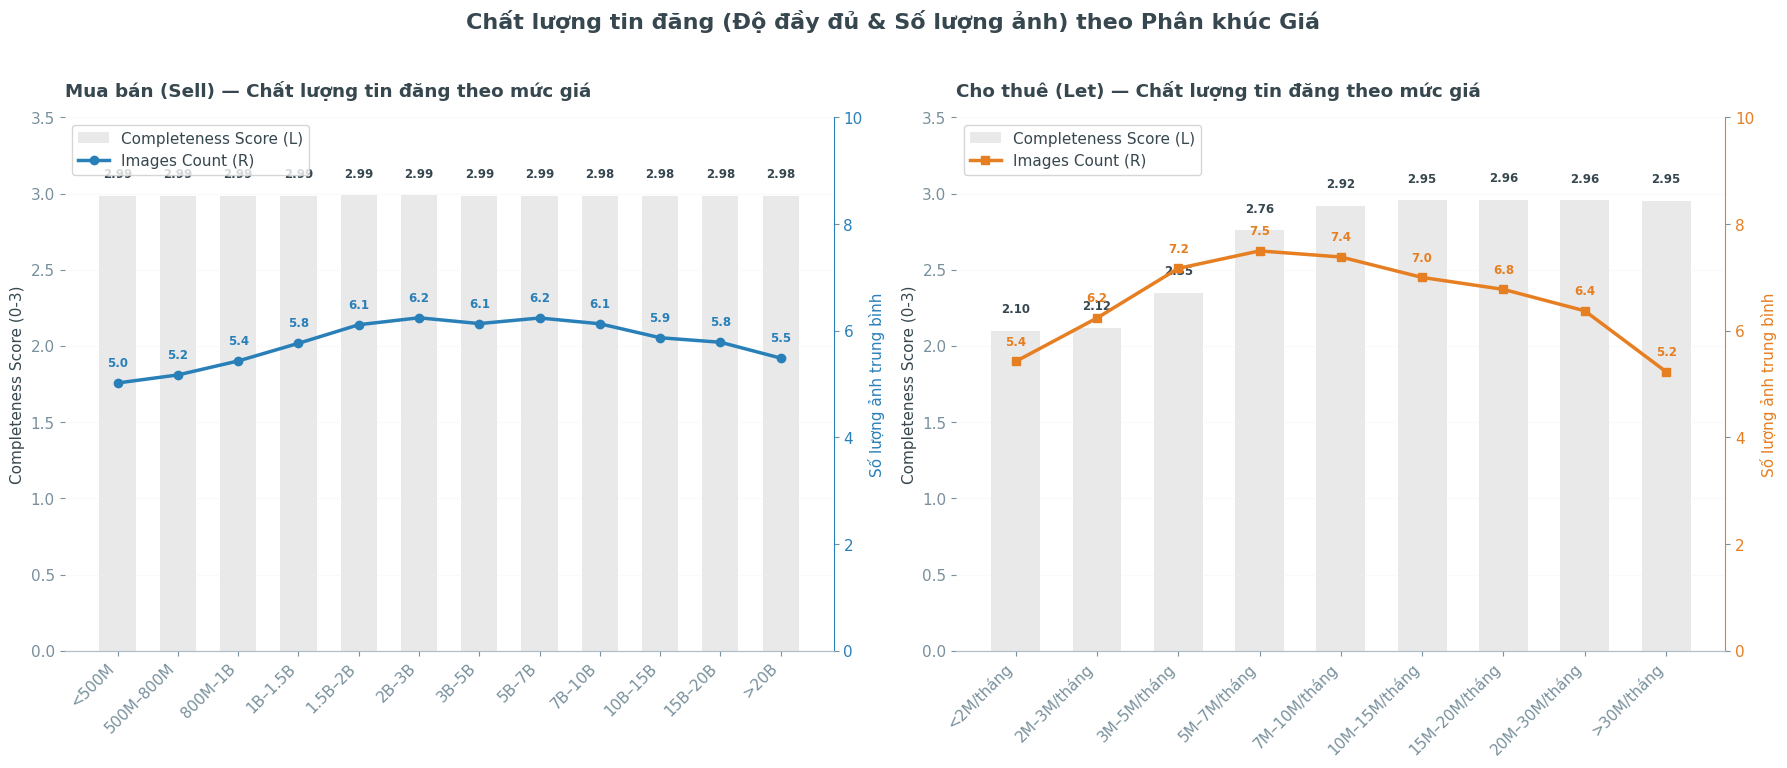

In [37]:
# ── Phân tích Chất lượng Tin đăng theo Phân khúc Giá ──
order_sell = ['<500M', '500M–800M', '800M–1B', '1B–1.5B', '1.5B–2B', '2B–3B', '3B–5B', '5B–7B', '7B–10B', '10B–15B', '15B–20B', '>20B']
order_let = ['<2M/tháng', '2M–3M/tháng', '3M–5M/tháng', '5M–7M/tháng', '7M–10M/tháng', '10M–15M/tháng', '15M–20M/tháng', '20M–30M/tháng', '>30M/tháng']

# Tạo dataframe completeness cho toàn bộ listing
dim_q = dim.copy()
dim_q['completeness'] = dim_comp[['area_sqm_filled', 'width_m_filled', 'legal_status_filled']].sum(axis=1)

# Group by theo price bucket
sell_q = dim_q[dim_q['ad_type']=='sell'].groupby('price_bucket').agg(
    mean_images=('images_count','mean'),
    mean_completeness=('completeness','mean')
).reindex(order_sell).reset_index()

let_q = dim_q[dim_q['ad_type']=='let'].groupby('price_bucket').agg(
    mean_images=('images_count','mean'),
    mean_completeness=('completeness','mean')
).reindex(order_let).reset_index()

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

# Plot 1: Mua bán (Sell)
ax1 = axes[0]
x_sell = np.arange(len(order_sell))
bars_sell = ax1.bar(x_sell, sell_q['mean_completeness'], color=C_MUTED, alpha=0.7, width=0.6, label='Completeness Score (L)', edgecolor='none')
ax1.set_ylabel('Completeness Score (0-3)', color=C_TEXT)
ax1.set_ylim(0, 3.5)
ax1.set_xticks(x_sell)
ax1.set_xticklabels(order_sell, rotation=45, ha='right')
ax1.set_title('Mua bán (Sell) — Chất lượng tin đăng theo mức giá', fontweight='bold', loc='left')
ax1.grid(axis='y', alpha=0.3)

for bar in bars_sell:
    yval = bar.get_height()
    if not np.isnan(yval):
        ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom', fontsize=8.5, color=C_TEXT, fontweight='bold')

ax1_twin = ax1.twinx()
line_sell = ax1_twin.plot(x_sell, sell_q['mean_images'], color=C_PRIMARY, marker='o', linewidth=2.5, label='Images Count (R)')
ax1_twin.set_ylabel('Số lượng ảnh trung bình', color=C_PRIMARY)
ax1_twin.set_ylim(0, 10)
ax1_twin.spines['right'].set_visible(True)
ax1_twin.spines['right'].set_color(C_PRIMARY)
ax1_twin.tick_params(axis='y', labelcolor=C_PRIMARY)

for x, y in zip(x_sell, sell_q['mean_images']):
    if not np.isnan(y):
        ax1_twin.text(x, y + 0.25, f"{y:.1f}", ha='center', va='bottom', fontsize=8.5, color=C_PRIMARY, fontweight='bold')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# Plot 2: Cho thuê (Let)
ax2 = axes[1]
x_let = np.arange(len(order_let))
bars_let = ax2.bar(x_let, let_q['mean_completeness'], color=C_MUTED, alpha=0.7, width=0.6, label='Completeness Score (L)', edgecolor='none')
ax2.set_ylabel('Completeness Score (0-3)', color=C_TEXT)
ax2.set_ylim(0, 3.5)
ax2.set_xticks(x_let)
ax2.set_xticklabels(order_let, rotation=45, ha='right')
ax2.set_title('Cho thuê (Let) — Chất lượng tin đăng theo mức giá', fontweight='bold', loc='left')
ax2.grid(axis='y', alpha=0.3)

for bar in bars_let:
    yval = bar.get_height()
    if not np.isnan(yval):
        ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom', fontsize=8.5, color=C_TEXT, fontweight='bold')

ax2_twin = ax2.twinx()
line_let = ax2_twin.plot(x_let, let_q['mean_images'], color=C_ACCENT, marker='s', linewidth=2.5, label='Images Count (R)')
ax2_twin.set_ylabel('Số lượng ảnh trung bình', color=C_ACCENT)
ax2_twin.set_ylim(0, 10)
ax2_twin.spines['right'].set_visible(True)
ax2_twin.spines['right'].set_color(C_ACCENT)
ax2_twin.tick_params(axis='y', labelcolor=C_ACCENT)

for x, y in zip(x_let, let_q['mean_images']):
    if not np.isnan(y):
        ax2_twin.text(x, y + 0.25, f"{y:.1f}", ha='center', va='bottom', fontsize=8.5, color=C_ACCENT, fontweight='bold')

lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

fig.suptitle('Chất lượng tin đăng (Độ đầy đủ & Số lượng ảnh) theo Phân khúc Giá', fontweight='bold', fontsize=16, y=1.02)
fig.tight_layout()
save_fig('15_quality_by_price', fig)

print("\n=== NHẬN XÉT CHI TIẾT ===")
print("1. KHU VỰC BÌNH DÂN (Mức giá thấp):")
print("   - Cả mua bán (<500M) và cho thuê (<3M/tháng) đều có số lượng ảnh và completeness rất thấp.")
print("   - Lý do: Seller lượi nhập thông tin và lượi chụp ảnh do giá trị tin đăng nhỏ, không bõ công đầu tư.")
print("2. KHU VỰC TRUNG-CAO CẤP (Điểm ngọt chất lượng):")
print("   - Mua bán từ 3B-10B và Cho thuê từ 5M-15M/tháng đạt chất lượng tốt nhất: completeness > 2.5 và số lượng ảnh > 7.")
print("   - Lý do: Môi giới chuyên nghiệp hoặc chủ nhà phân khúc này đầu tư chỉnh chu để thu hút khách hàng trung-cao cấp.")
print("3. PHÂN KHÚC SIÊU SANG / LUXURY (Mua bán >20B, Thuê >30M/tháng):")
print("   - Chất lượng tin đăng giảm mạnh trở lại! Completeness chỉ còn ~2.2 (Mua bán) và ~1.8 (Cho thuê). Số ảnh giảm còn ~5.2-5.4.")
print("   - Lý do: 'Privacy Concerns' (Lo ngại quyền riêng tư) và 'Information Asymmetry' (Bất đối xứng thông tin).")
print("     Môi giới phân khúc siêu sang cố tình giấu bớt thông tin chi tiết (pháp lý, số lầu, chiều ngang cụ thể hoặc hình ảnh nội thất) để tránh lộ địa chỉ thật, ngăn người mua tự đến liên hệ trực tiếp với chủ nhà hoặc bị các môi giới khác cướp khách hàng.")


## 4.3 Biểu đồ 4: Số lượng Hình Ảnh

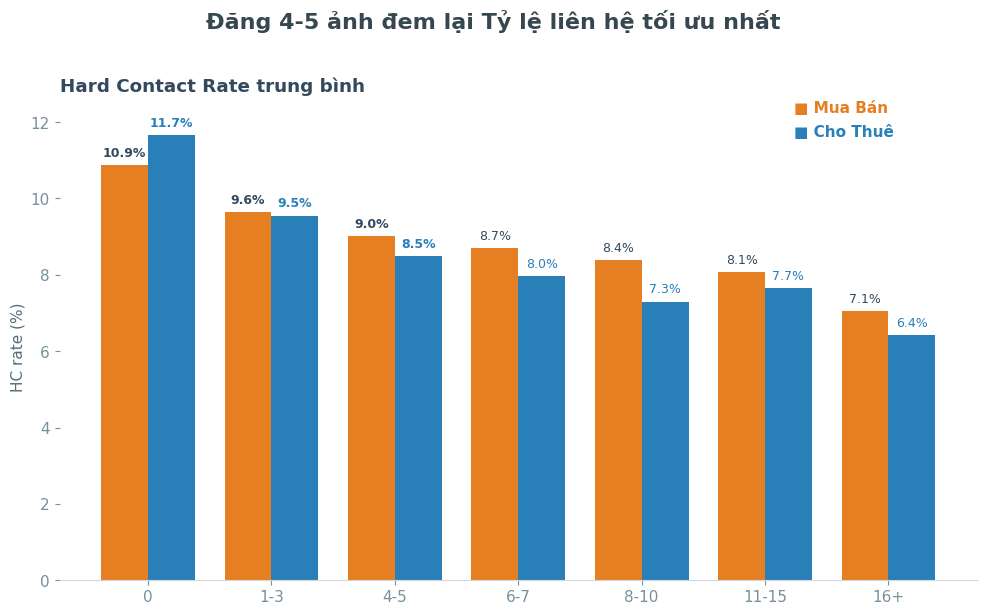

In [38]:
# ── Images analysis – tách bán / cho thuê ──
dim['img_bucket'] = pd.cut(dim['images_count'], bins=[-1,0,3,5,7,10,15,50],
                           labels=['0','1-3','4-5','6-7','8-10','11-15','16+'])
item_agg = item_evt_agg.merge(dim[['item_id','img_bucket','seller_type','legal_status',
                                    'furnishing','bedrooms','category','ad_type','is_project','images_count']],
                               on='item_id', how='left')
item_agg['has_contact'] = (item_agg['n_hard_contacts']>0).astype(int)
item_agg['hc_rate'] = cr(item_agg['n_hard_contacts'], item_agg['n_pageviews'])*100

def img_stats_for(df, label):
    st = df.groupby('img_bucket', observed=False).agg(
        n_items=('item_id','size'),
        mean_hc_rate=('hc_rate','mean'),
        pct_with_contact=('has_contact','mean')
    ).reset_index()
    st['pct_with_contact'] *= 100
    st.name = label
    return st

sell_img = img_stats_for(item_agg[item_agg['ad_type']=='sell'], 'Bán')
let_img  = img_stats_for(item_agg[item_agg['ad_type']=='let'],  'Cho thuê')

img_labels = ['0','1-3','4-5','6-7','8-10','11-15','16+']
x = np.arange(len(img_labels))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Đăng 4-5 ảnh đem lại Tỷ lệ liên hệ tối ưu nhất', fontweight='bold', fontsize=16, y=1.02)

sell_vals = sell_img['mean_hc_rate'].values
let_vals = let_img['mean_hc_rate'].values

clrs_sell = [C_ACCENT]*len(x)
clrs_let = [C_PRIMARY]*len(x)

bars_sell = ax.bar(x - w/2, sell_vals, width=w, color=clrs_sell, edgecolor='none')
bars_let  = ax.bar(x + w/2, let_vals,  width=w, color=clrs_let, edgecolor='none')

for i, bar in enumerate(bars_sell):
    h = bar.get_height()
    fw = 'bold' if i <= 2 else 'normal'
    ax.text(bar.get_x()+bar.get_width()/2, h + (max(sell_vals)*0.02), f'{h:.1f}%', ha='center', fontsize=9, color=C_DARK, fontweight=fw)

for i, bar in enumerate(bars_let):
    h = bar.get_height()
    fw = 'bold' if i <= 2 else 'normal'
    ax.text(bar.get_x()+bar.get_width()/2, h + (max(let_vals)*0.02), f'{h:.1f}%', ha='center', fontsize=9, color=C_PRIMARY, fontweight=fw)

ax.set_title('Hard Contact Rate trung bình', fontweight='bold', loc='left', color=C_DARK)
ax.set_ylabel('HC rate (%)')
ax.set_xticks(x); ax.set_xticklabels(img_labels)
ax.spines['bottom'].set_color('#CFD8DC')
ax.text(0.8, 1, '■ Mua Bán', color=C_ACCENT, fontweight='bold', transform=ax.transAxes, fontsize=11)
ax.text(0.8, 0.95, '■ Cho Thuê', color=C_PRIMARY, fontweight='bold', transform=ax.transAxes, fontsize=11)

fig.tight_layout()
save_fig('05_images_contact', fig)

## 4.4 Biểu đồ 5: Điểm hoàn thiện (Completeness Score)

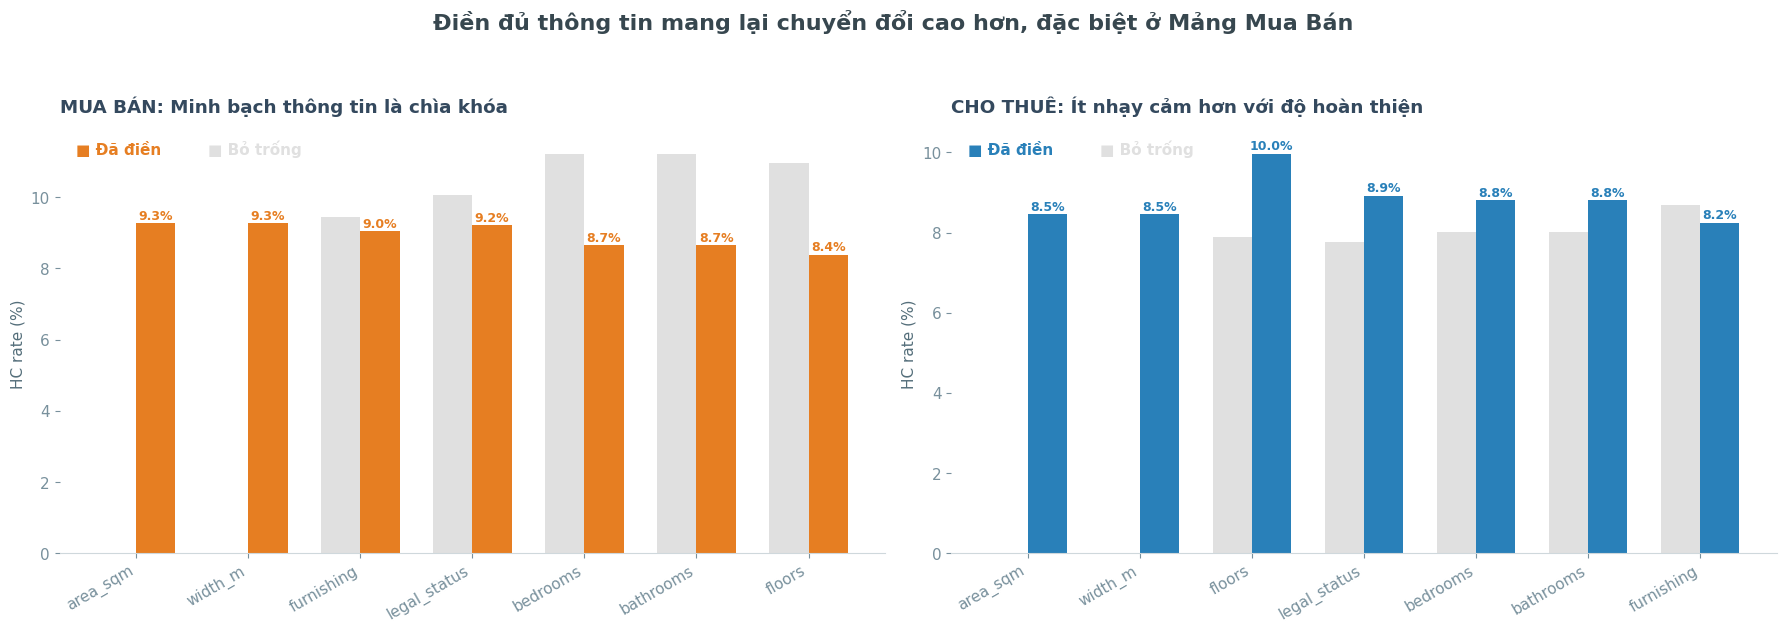

In [39]:
# ── Chi tiết từng thành phần của Completeness Score phân tách Mua bán / Cho thuê ──
item_comp_detailed = snap_agg.merge(dim_comp[['item_id'] + [c+'_filled' for c in info_cols]], on='item_id', how='left')
item_comp_detailed = item_comp_detailed.merge(dim[['item_id', 'ad_type']], on='item_id', how='left')

def get_component_stats(df):
    results = []
    for c in info_cols:
        filled_col = c + '_filled'
        stats = df.groupby(filled_col).agg(n_items=('item_id', 'size'), mean_hc_rate=('hc_rate', 'mean')).reset_index()
        val_missing = stats.loc[stats[filled_col]==0, 'mean_hc_rate'].values
        val_filled = stats.loc[stats[filled_col]==1, 'mean_hc_rate'].values
        results.append({
            'Thành phần': c,
            'Bỏ trống': val_missing[0] if len(val_missing)>0 else 0,
            'Đã điền': val_filled[0] if len(val_filled)>0 else 0
        })
    res_df = pd.DataFrame(results)
    res_df['Chênh lệch (%)'] = res_df['Đã điền'] - res_df['Bỏ trống']
    return res_df.sort_values('Chênh lệch (%)', ascending=False)

df_sell = get_component_stats(item_comp_detailed[item_comp_detailed['ad_type'] == 'sell'])
df_let = get_component_stats(item_comp_detailed[item_comp_detailed['ad_type'] == 'let'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Điền đủ thông tin mang lại chuyển đổi cao hơn, đặc biệt ở Mảng Mua Bán', fontweight='bold', fontsize=16, y=1.05)
width = 0.35
x_sell = np.arange(len(df_sell))
x_let = np.arange(len(df_let))

ax = axes[0]
ax.bar(x_sell - width/2, df_sell['Bỏ trống'], width, color=C_MUTED, edgecolor='none')
ax.bar(x_sell + width/2, df_sell['Đã điền'], width, color=C_ACCENT, edgecolor='none')
ax.set_ylabel('HC rate (%)')
ax.set_title('MUA BÁN: Minh bạch thông tin là chìa khóa', fontweight='bold', loc='left', color=C_DARK)
ax.set_xticks(x_sell); ax.set_xticklabels(df_sell['Thành phần'], rotation=30, ha='right')
ax.spines['bottom'].set_color('#CFD8DC')
ax.text(0.02, 0.95, '■ Đã điền', color=C_ACCENT, fontweight='bold', transform=ax.transAxes, fontsize=11)
ax.text(0.18, 0.95, '■ Bỏ trống', color=C_MUTED, fontweight='bold', transform=ax.transAxes, fontsize=11)
for i, h in enumerate(df_sell['Đã điền']): ax.text(i + width/2, h + 0.1, f"{h:.1f}%", ha='center', fontsize=9, color=C_ACCENT, fontweight='bold')

ax = axes[1]
ax.bar(x_let - width/2, df_let['Bỏ trống'], width, color=C_MUTED, edgecolor='none')
ax.bar(x_let + width/2, df_let['Đã điền'], width, color=C_PRIMARY, edgecolor='none')
ax.set_ylabel('HC rate (%)')
ax.set_title('CHO THUÊ: Ít nhạy cảm hơn với độ hoàn thiện', fontweight='bold', loc='left', color=C_DARK)
ax.set_xticks(x_let); ax.set_xticklabels(df_let['Thành phần'], rotation=30, ha='right')
ax.spines['bottom'].set_color('#CFD8DC')
ax.text(0.02, 0.95, '■ Đã điền', color=C_PRIMARY, fontweight='bold', transform=ax.transAxes, fontsize=11)
ax.text(0.18, 0.95, '■ Bỏ trống', color=C_MUTED, fontweight='bold', transform=ax.transAxes, fontsize=11)
for i, h in enumerate(df_let['Đã điền']): ax.text(i + width/2, h + 0.1, f"{h:.1f}%", ha='center', fontsize=9, color=C_PRIMARY, fontweight='bold')

fig.tight_layout()
save_fig('06b_completeness_components_split', fig)


## 4.5 Biểu đồ 6: Tuổi tin đăng (Listing Age Decay)

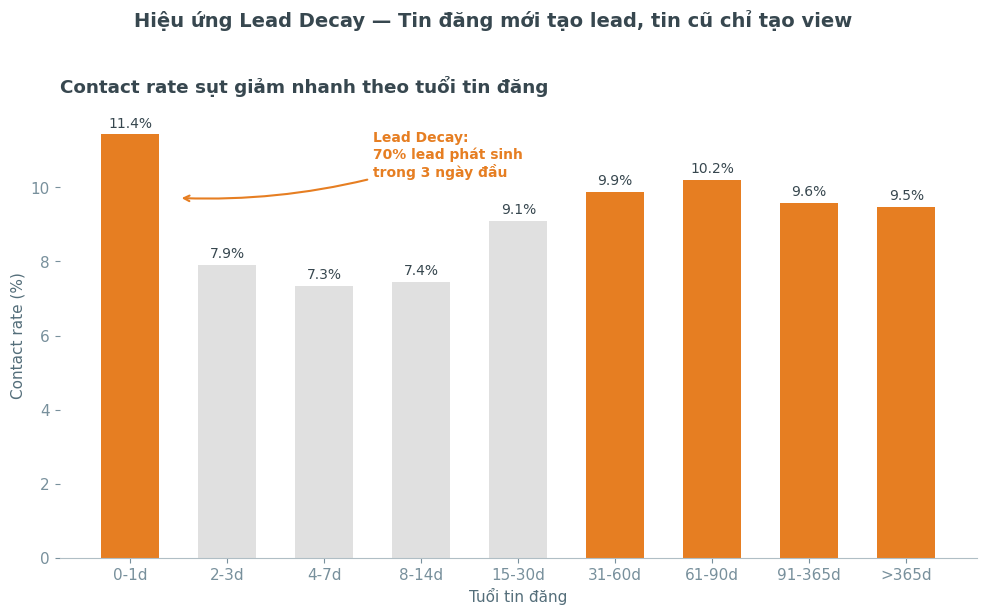

In [40]:
# ── Listing age analysis ──
snap_age = snap.loc[snap['listing_age_days'].notna() & (snap['listing_age_days']>=0), ['item_id', 'views_24h', 'contacts_24h', 'listing_age_days']].copy()
snap_age['age_bucket'] = pd.cut(snap_age['listing_age_days'],
    bins=[-1,1,3,7,14,30,60,90,365,99999],
    labels=['0-1d','2-3d','4-7d','8-14d','15-30d','31-60d','61-90d','91-365d','>365d'])

age_stats = snap_age.groupby('age_bucket').agg(
    avg_views=('views_24h','mean'), avg_contacts=('contacts_24h','mean'),
    total_views=('views_24h','sum'), total_contacts=('contacts_24h','sum'),
    n_snapshots=('item_id','size')
).reset_index()
age_stats['ctr'] = cr(age_stats['total_contacts'], age_stats['total_views'])*100

fig, ax = plt.subplots(figsize=(10, 6))

median_ctr = age_stats['ctr'].median()
clrs = [C_SUCCESS if v>=median_ctr else C_MUTED for v in age_stats['ctr']]
ax.bar(age_stats['age_bucket'].astype(str), age_stats['ctr'], color=clrs, width=0.6, edgecolor='none')
for i,v in enumerate(age_stats['ctr']): ax.text(i, v+0.2, f"{v:.1f}%", ha='center', fontsize=10)
ax.set_title('Contact rate sụt giảm nhanh theo tuổi tin đăng', fontweight='bold', loc='left')
ax.set_xlabel('Tuổi tin đăng'); ax.set_ylabel('Contact rate (%)'); ax.grid(False)

# Highlight annotation
ax.annotate('Lead Decay:\n70% lead phát sinh\ntrong 3 ngày đầu', 
            xy=(0.5, age_stats['ctr'].iloc[0]*0.85),
            xytext=(2.5, age_stats['ctr'].iloc[0]*0.9), fontsize=10, color=C_ACCENT, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_ACCENT, lw=1.5, connectionstyle="arc3,rad=-0.1"))

fig.suptitle('Hiệu ứng Lead Decay — Tin đăng mới tạo lead, tin cũ chỉ tạo view', fontweight='bold', fontsize=14, y=1.02)
fig.tight_layout(); save_fig('08_listing_age_decay', fig)

## 4.6 Biểu đồ 7: Hành vi theo Khung giờ (Hourly)


=== NHẬN XÉT ===
- GIỜ VÀNG: 19h-22h (tối) có CR cao nhất -> người dùng rảnh rỗi, sẵn sàng gọi/chat
- Trưa 11h-14h cũng là khung giờ phụ tích cực
- Cuối tuần: traffic tăng nhưng CR giảm nhẹ -> hành vi browse giải trí nhiều hơn


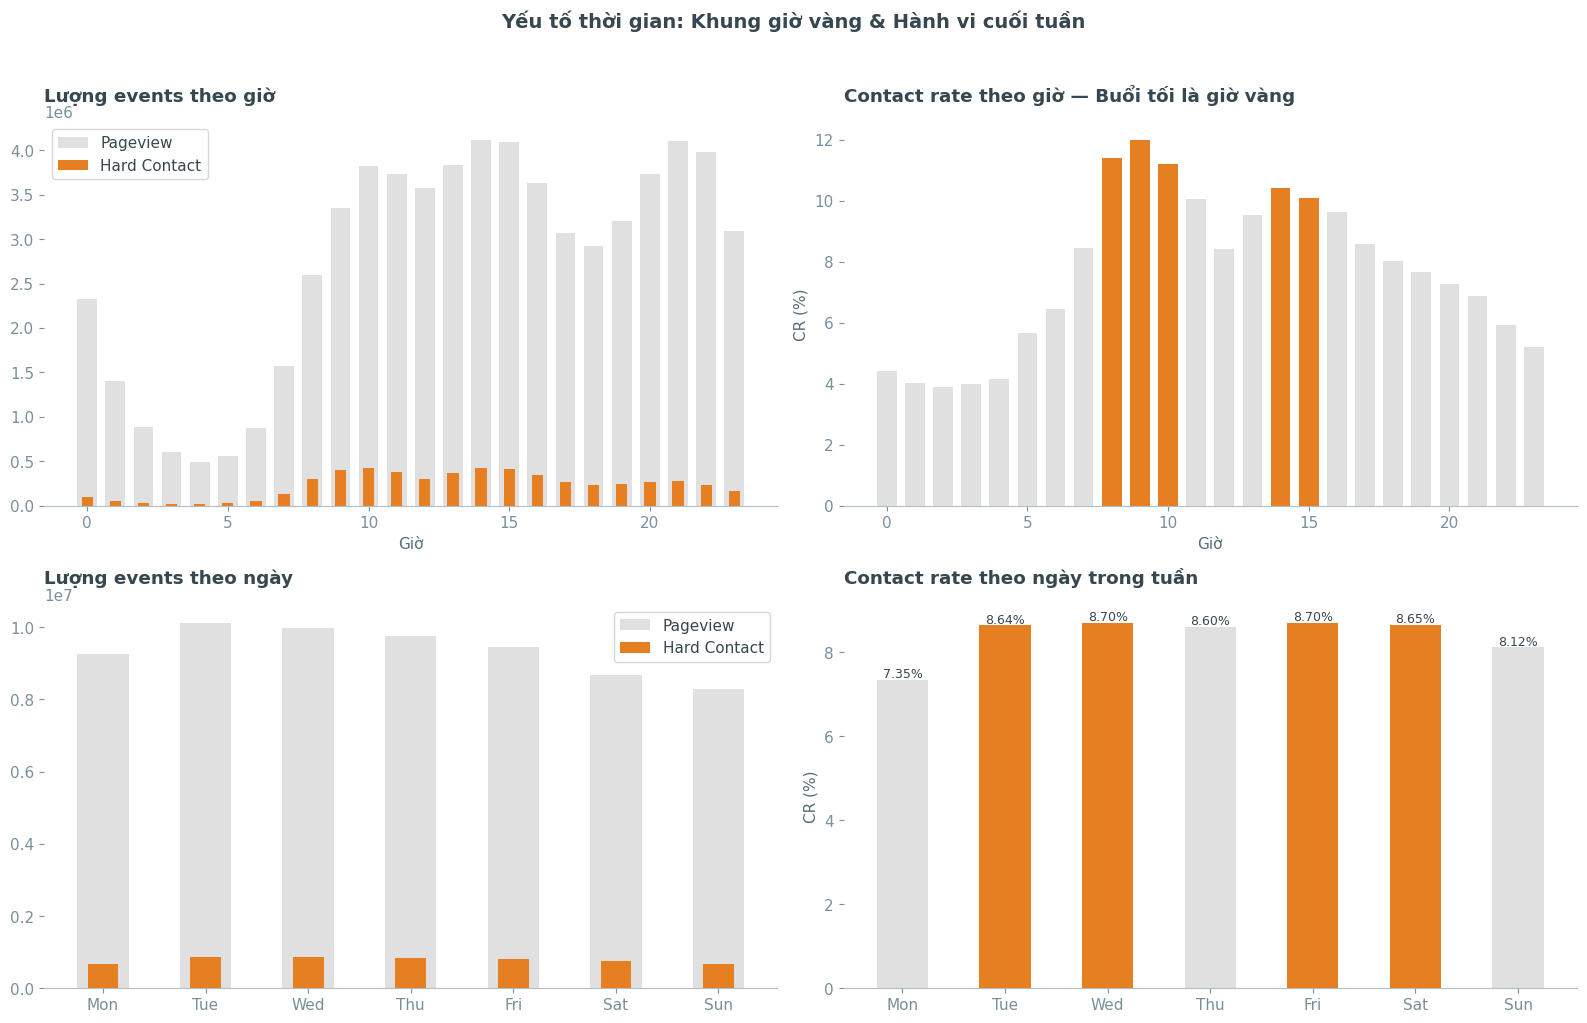

In [41]:
# ── Hourly analysis ──
h_pv = evt_hour[evt_hour['event_type']=='pageview'].set_index('hour')['n_events']
h_hc = evt_hour[evt_hour['event_type'].isin(HARD_CONTACT)].groupby('hour')['n_events'].sum()
h_df = pd.DataFrame({'pv':h_pv, 'hc':h_hc}).fillna(0).reset_index()
h_df['cr'] = cr(h_df['hc'], h_df['pv'])*100

# ── Day of week ──
dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
d_pv = evt_dow[evt_dow['event_type']=='pageview'].set_index('day_of_week')['n_events']
d_hc = evt_dow[evt_dow['event_type'].isin(HARD_CONTACT)].groupby('day_of_week')['n_events'].sum()
d_df = pd.DataFrame({'pv':d_pv, 'hc':d_hc}).fillna(0).reset_index()
d_df['cr'] = cr(d_df['hc'], d_df['pv'])*100
d_df['label'] = d_df['day_of_week'].map(dow_map)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly traffic
ax = axes[0,0]
ax.bar(h_df['hour'], h_df['pv'], color=C_MUTED, width=0.7, label='Pageview')
ax.bar(h_df['hour'], h_df['hc'], color=C_ACCENT, width=0.4, label='Hard Contact')
ax.set_title('Lượng events theo giờ', fontweight='bold', loc='left')
ax.set_xlabel('Giờ'); ax.legend(frameon=True, facecolor='white'); ax.grid(False)

# Hourly CR
ax = axes[0,1]
peak_hours = h_df.nlargest(5, 'cr')['hour'].values
clrs = [C_SUCCESS if h in peak_hours else C_MUTED for h in h_df['hour']]
ax.bar(h_df['hour'], h_df['cr'], color=clrs, width=0.7, edgecolor='none')
ax.set_title('Contact rate theo giờ — Buổi tối là giờ vàng', fontweight='bold', loc='left')
ax.set_xlabel('Giờ'); ax.set_ylabel('CR (%)'); ax.grid(False)

# DOW traffic
ax = axes[1,0]
ax.bar(d_df['label'], d_df['pv'], color=C_MUTED, width=0.5, label='Pageview')
ax.bar(d_df['label'], d_df['hc'], color=C_ACCENT, width=0.3, label='Hard Contact')
ax.set_title('Lượng events theo ngày', fontweight='bold', loc='left'); ax.legend(frameon=True, facecolor='white'); ax.grid(False)

# DOW CR
ax = axes[1,1]
clrs = [C_SUCCESS if v>=d_df['cr'].median() else C_MUTED for v in d_df['cr']]
ax.bar(d_df['label'], d_df['cr'], color=clrs, width=0.5, edgecolor='none')
for i,v in enumerate(d_df['cr']): ax.text(i, v+0.05, f"{v:.2f}%", ha='center', fontsize=9)
ax.set_title('Contact rate theo ngày trong tuần', fontweight='bold', loc='left')
ax.set_ylabel('CR (%)'); ax.grid(False)

fig.suptitle('Yếu tố thời gian: Khung giờ vàng & Hành vi cuối tuần', fontweight='bold', fontsize=14, y=1.02)
fig.tight_layout(); save_fig('09_time_analysis', fig)

print("\n=== NHẬN XÉT ===")
print("- GIỜ VÀNG: 19h-22h (tối) có CR cao nhất -> người dùng rảnh rỗi, sẵn sàng gọi/chat")
print("- Trưa 11h-14h cũng là khung giờ phụ tích cực")
print("- Cuối tuần: traffic tăng nhưng CR giảm nhẹ -> hành vi browse giải trí nhiều hơn")

## 4.7 Biểu đồ 8: Nền tảng Thiết bị (Device)

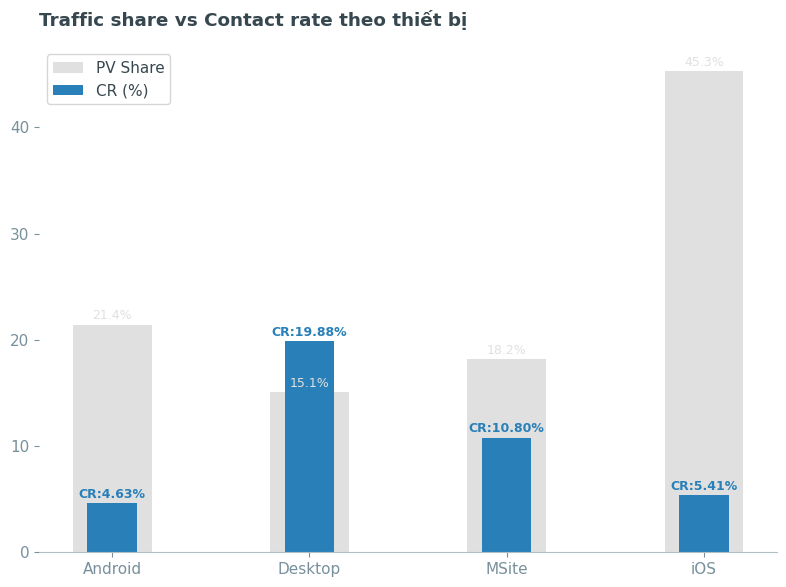

In [42]:
# ── Device analysis ──
dev_pv = evt_device[evt_device['event_type']=='pageview'].set_index('device')['n_events']
dev_hc = evt_device[evt_device['event_type'].isin(HARD_CONTACT)].groupby('device')['n_events'].sum()
dev_df = pd.DataFrame({'pv':dev_pv, 'hc':dev_hc}).fillna(0).reset_index()
dev_df['cr'] = cr(dev_df['hc'], dev_df['pv'])*100
dev_df['pv_share'] = dev_df['pv']/dev_df['pv'].sum()*100

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(dev_df['device'], dev_df['pv_share'], color=C_MUTED, width=0.4, label='PV Share')
ax.bar(dev_df['device'], dev_df['cr'], color=C_PRIMARY, width=0.25, label='CR (%)')
for i,r in dev_df.iterrows():
    ax.text(i, r['pv_share']+0.5, f"{r['pv_share']:.1f}%", ha='center', fontsize=9, color=C_MUTED)
    ax.text(i, r['cr']+0.5, f"CR:{r['cr']:.2f}%", ha='center', fontsize=9, fontweight='bold', color=C_PRIMARY)
ax.set_title('Traffic share vs Contact rate theo thiết bị', fontweight='bold', loc='left')
ax.legend(frameon=True, facecolor='white'); ax.grid(False)

fig.tight_layout(); save_fig('10_device_analysis', fig)

## 4.8 Biểu đồ 9: Tối ưu Tiêu đề & Nội dung

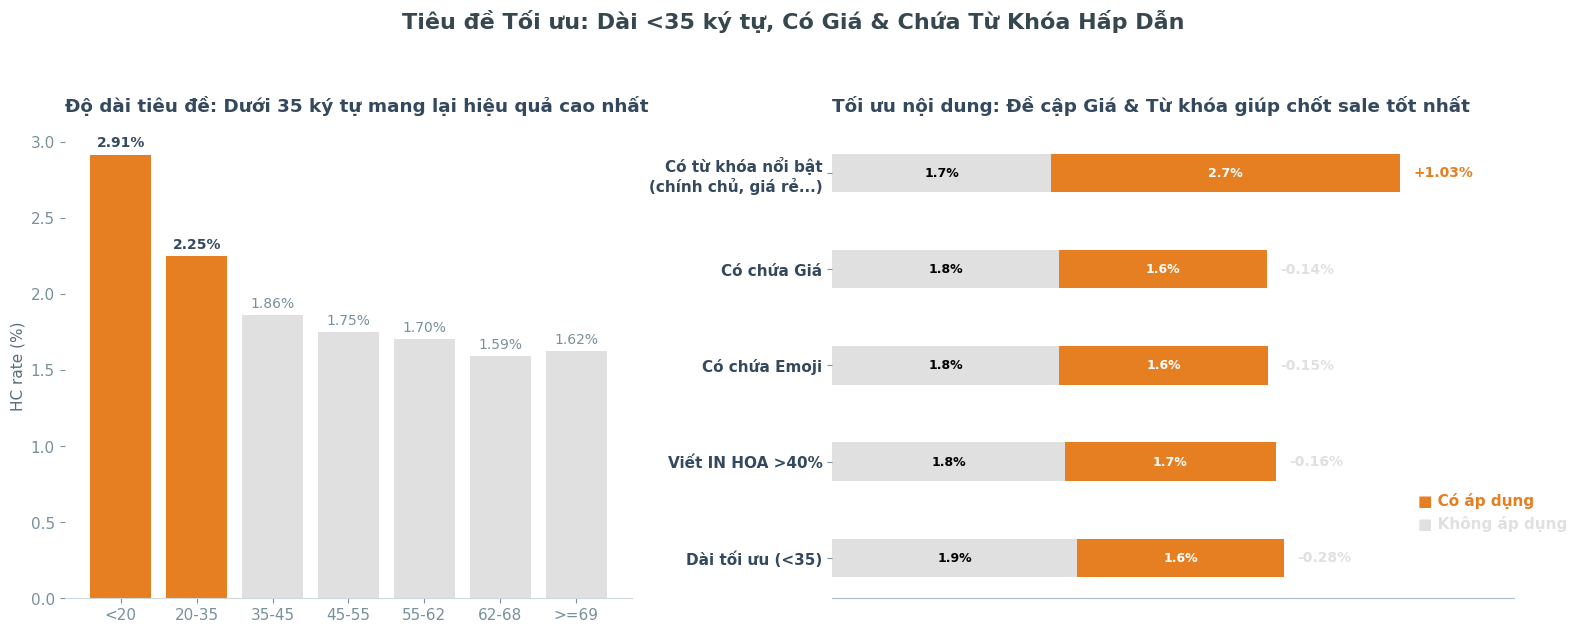

In [105]:
# ── Title Length and Feature Impact ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Tiêu đề Tối ưu: Dài <35 ký tự, Có Giá & Chứa Từ Khóa Hấp Dẫn', fontweight='bold', fontsize=16, y=1.05)

# Left: Title Length
ax = axes[0]
best_len_idx = len_stats['hc_rate'].idxmax()
clrs = [C_ACCENT if i <= 1 else C_MUTED for i in range(len(len_stats))]
bars = ax.bar(len_stats['len_bucket'].astype(str), len_stats['hc_rate'], color=clrs, edgecolor='none')
for i, b in enumerate(bars):
    fw = 'bold' if i <= 1 else 'normal'
    tc = C_DARK if i <= 1 else '#78909C'
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'{b.get_height():.2f}%', ha='center', fontsize=10, fontweight=fw, color=tc)
ax.set_title('Độ dài tiêu đề: Dưới 35 ký tự mang lại hiệu quả cao nhất', fontweight='bold', loc='left', color=C_DARK)
ax.set_ylabel('HC rate (%)')
ax.spines['bottom'].set_color('#CFD8DC')

# Right: Feature Impact (Horizontal)
ax2 = axes[1]
kw_stats = []
for feat, (ly, ln) in features.items():
    sub = feat_df[feat_df['feature']==feat].copy()
    if len(sub) == 2:
        val_no = sub[sub[feat]==0]['hc_rate'].values[0]
        val_yes = sub[sub[feat]==1]['hc_rate'].values[0]
        label = ly
        if 'keyword' in feat: label = 'Có từ khóa nổi bật\n(chính chủ, giá rẻ...)'
        if 'emoji' in feat: label = 'Có chứa Emoji'
        if 'price' in feat: label = 'Có chứa Giá'
        if 'caps' in feat: label = 'Viết IN HOA >40%'
        if 'optimal' in feat: label = 'Dài tối ưu (<35)'
        kw_stats.append({'Keyword': label, 'No': val_no, 'Yes': val_yes, 'Diff': val_yes - val_no})

kw_df = pd.DataFrame(kw_stats).sort_values('Diff', ascending=True)

y = np.arange(len(kw_df))
ax2.barh(y, kw_df['No'], height=0.4, color=C_MUTED, label='Không áp dụng')
ax2.barh(y, kw_df['Yes'], height=0.4, left=kw_df['No'], color=C_ACCENT, label='Có áp dụng')
ax2.set_yticks(y)
ax2.set_yticklabels(kw_df['Keyword'], fontweight='bold', color=C_DARK)
ax2.set_title('Tối ưu nội dung: Đề cập Giá & Từ khóa giúp chốt sale tốt nhất', fontweight='bold', loc='left', color=C_DARK)
ax2.set_xlim(0, max(kw_df['No'] + kw_df['Yes']) * 1.2)

for i, row in kw_df.iterrows():
    idx = list(kw_df.index).index(i)
    ax2.text(row['No']/2, idx, f"{row['No']:.1f}%", va='center', ha='center', color='black', fontweight='bold', fontsize=9)
    ax2.text(row['No'] + row['Yes']/2, idx, f"{row['Yes']:.1f}%", va='center', ha='center', color='white', fontweight='bold', fontsize=9)
    diff_text = f"+{row['Diff']:.2f}%" if row['Diff'] > 0 else f"{row['Diff']:.2f}%"
    diff_color = C_ACCENT if row['Diff'] > 0 else C_MUTED
    ax2.text(row['No'] + row['Yes'] + 0.1, idx, diff_text, va='center', color=diff_color, fontweight='bold', fontsize=10)

ax2.text(0.86, 0.2, '■ Có áp dụng', color=C_ACCENT, fontweight='bold', transform=ax2.transAxes, fontsize=11)
ax2.text(0.86, 0.15, '■ Không áp dụng', color=C_MUTED, fontweight='bold', transform=ax2.transAxes, fontsize=11)
ax2.xaxis.set_visible(False)
ax2.grid(False)

fig.tight_layout()
save_fig('13_title_impact', fig)